# Clasificación de Puntos del Espacio Paramétrico según Condiciones Físicas

Este notebook explora un dataset obtenido de un escaneo de parámetros (con columnas como `m_phi`, `mA`, `alpha`, `beta`, `lambda6`, `lambda7`, `m12`, etc.) y asigna una etiqueta (label) a cada punto dependiendo de la condición física que se desea evaluar.  
Las condiciones disponibles son:

- **a. Sin ninguna restricción:** Todos los puntos se consideran positivos.
- **b. Solo unitariedad:** Se etiqueta 1 si `unitarity_ok` es 1.
- **c. Solo perturbatividad:** Se etiqueta 1 si `perturbativity_ok` es 1.
- **d. Solo positividad:** Se etiqueta 1 si `positivity_ok` es 1.
- **bcd. Las 3 juntas:** Se etiqueta 1 si los tres flags son 1.
- **cd. Perturbatividad y positividad:** Se etiqueta 1 si `perturbativity_ok` y `positivity_ok` son 1.

Luego se entrena un modelo de clasificación (en este ejemplo, se usa un clasificador simple de scikit-learn) y se visualizan las fronteras (usando reducción de dimensionalidad) para entender qué región del espacio de parámetros produce puntos que cumplen la condición.

Este pipeline nos servirá para separar el dataset en dos grupos y, posteriormente, aplicar técnicas heurísticas (incluyendo modelos bayesianos) para optimizar la búsqueda en el espacio de parámetros.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import random
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

# Configuración para gráficos
sns.set(style="whitegrid")
%matplotlib inline


In [2]:
# Suponiendo que los CSV se encuentran en la carpeta "outphys"
folder_csv = "../outphys_beta_0403"
file_pattern = os.path.join(folder_csv, "*.csv")
files = glob.glob(file_pattern)
print("Número de archivos encontrados:", len(files))

# Definir las columnas de interés (incluyendo flags)
param_cols = ["m_phi", "mA", "alpha", "beta", "lambda6", "lambda7", "m12"]
flag_cols = ["positivity_ok", "unitarity_ok", "perturbativity_ok"]
target_col = "branching_ratio_h2_gaga"  # Este podría ser usado en análisis posterior

# Para este ejemplo, cargamos todos los CSV en un único DataFrame (suponiendo que no es demasiado grande)
# En entornos de gran escala se recomienda usar chunks o Dask.
df_list = []
for f in files:
    try:
        df = pd.read_csv(f)
        df_list.append(df)
    except Exception as e:
        print(f"Error al leer {f}: {e}")

data = pd.concat(df_list, ignore_index=True)
print("Dataset total:", data.shape)


Número de archivos encontrados: 1
Dataset total: (16032, 21)


In [3]:
# Mostrar las primeras filas y descripción general del dataset
display(data.head())
print(data.describe())
print(data[flag_cols].value_counts())


,Unnamed: 0,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivity_ok,unitarity_ok,...,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
0,0,125,320.0,-0.7,0.5,-0.5727,-1.0,-1.000000,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769151e-07,0.0,0.0,0.000127,0.01387
1,1,125,320.0,-0.7,0.5,-0.5727,-1.0,-0.565727,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769149e-07,0.0,0.0,0.000127,0.01387
2,2,125,320.0,-0.7,0.5,-0.5727,-1.0,-0.131454,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769147e-07,0.0,0.0,0.000127,0.01387
3,3,125,320.0,-0.7,0.5,-0.5727,-1.0,0.302819,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769144e-07,0.0,0.0,0.000127,0.01387
4,4,125,320.0,-0.7,0.5,-0.5727,-1.0,0.737092,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769142e-07,0.0,0.0,0.000127,0.01387


         Unnamed: 0         m_phi            mA         alpha          beta  \
count  16032.000000  16032.000000  16032.000000  16032.000000  16032.000000   
mean    8015.500000    290.011228    409.865269      0.021482      0.786751   
std     4628.184093    113.120101     73.459353      0.525188      0.218392   
min        0.000000    125.000000    320.000000     -0.700000      0.500000   
25%     4007.750000    215.000000    320.000000     -0.350000      0.674533   
50%     8015.500000    305.000000    410.000000      0.000000      0.849066   
75%    12023.250000    395.000000    500.000000      0.350000      0.849066   
max    16031.000000    485.000000    500.000000      0.700000      1.372665   

            lambda6       lambda7           m12  positivity_ok  unitarity_ok  \
count  16032.000000  16032.000000  16032.000000        16032.0       16032.0   
mean      -0.136445     -0.400149      0.085683            1.0           1.0   
std        0.566057      0.475692      0.741685 

In [4]:
def create_label(df, condition="all_three"):
    """
    Crea una columna 'label' en el DataFrame basado en la condición elegida.
    
    Parámetros:
      - df: DataFrame con los datos.
      - condition: String que define la condición. Opciones:
          "none": Sin restricción (todos positivos)
          "unitarity": solo unitariedad (unitarity_ok == 1)
          "perturbativity": solo perturbatividad (perturbativity_ok == 1)
          "positivity": solo positividad (positivity_ok == 1)
          "all_three": los 3 juntos (los 3 flags == 1)
          "perturbativity_positivity": perturbatividad y positividad (ambos == 1)
          
    Devuelve el DataFrame con una columna 'label' (1: cumple, 0: no cumple).
    """
    df = df.copy()
    if condition == "none":
        # Sin restricción: todos se etiquetan como 1 (o simplemente no filtrar)
        df['label'] = 1
    elif condition == "unitarity":
        df['label'] = df['unitarity_ok'].apply(lambda x: 1 if x == 1 else 0)
    elif condition == "perturbativity":
        df['label'] = df['perturbativity_ok'].apply(lambda x: 1 if x == 1 else 0)
    elif condition == "positivity":
        df['label'] = df['positivity_ok'].apply(lambda x: 1 if x == 1 else 0)
    elif condition == "all_three":
        df['label'] = ((df['unitarity_ok'] == 1) & (df['perturbativity_ok'] == 1) & (df['positivity_ok'] == 1)).astype(int)
    elif condition == "perturbativity_positivity":
        df['label'] = ((df['perturbativity_ok'] == 1) & (df['positivity_ok'] == 1)).astype(int)
    else:
        raise ValueError("Condición no reconocida.")
    return df

# Ejemplo: crear etiquetas para los puntos que cumplen las tres condiciones
condition_selected = "all_three"  # Puedes cambiar a "unitarity", "perturbativity", etc.
data_labeled = create_label(data, condition=condition_selected)
print("Distribución de etiquetas:")
print(data_labeled['label'].value_counts())


Distribución de etiquetas:
label
1    16032
Name: count, dtype: int64


In [5]:
N_samples = int(6e4)

Distribución de etiquetas:
label
1    16032
Name: count, dtype: int64


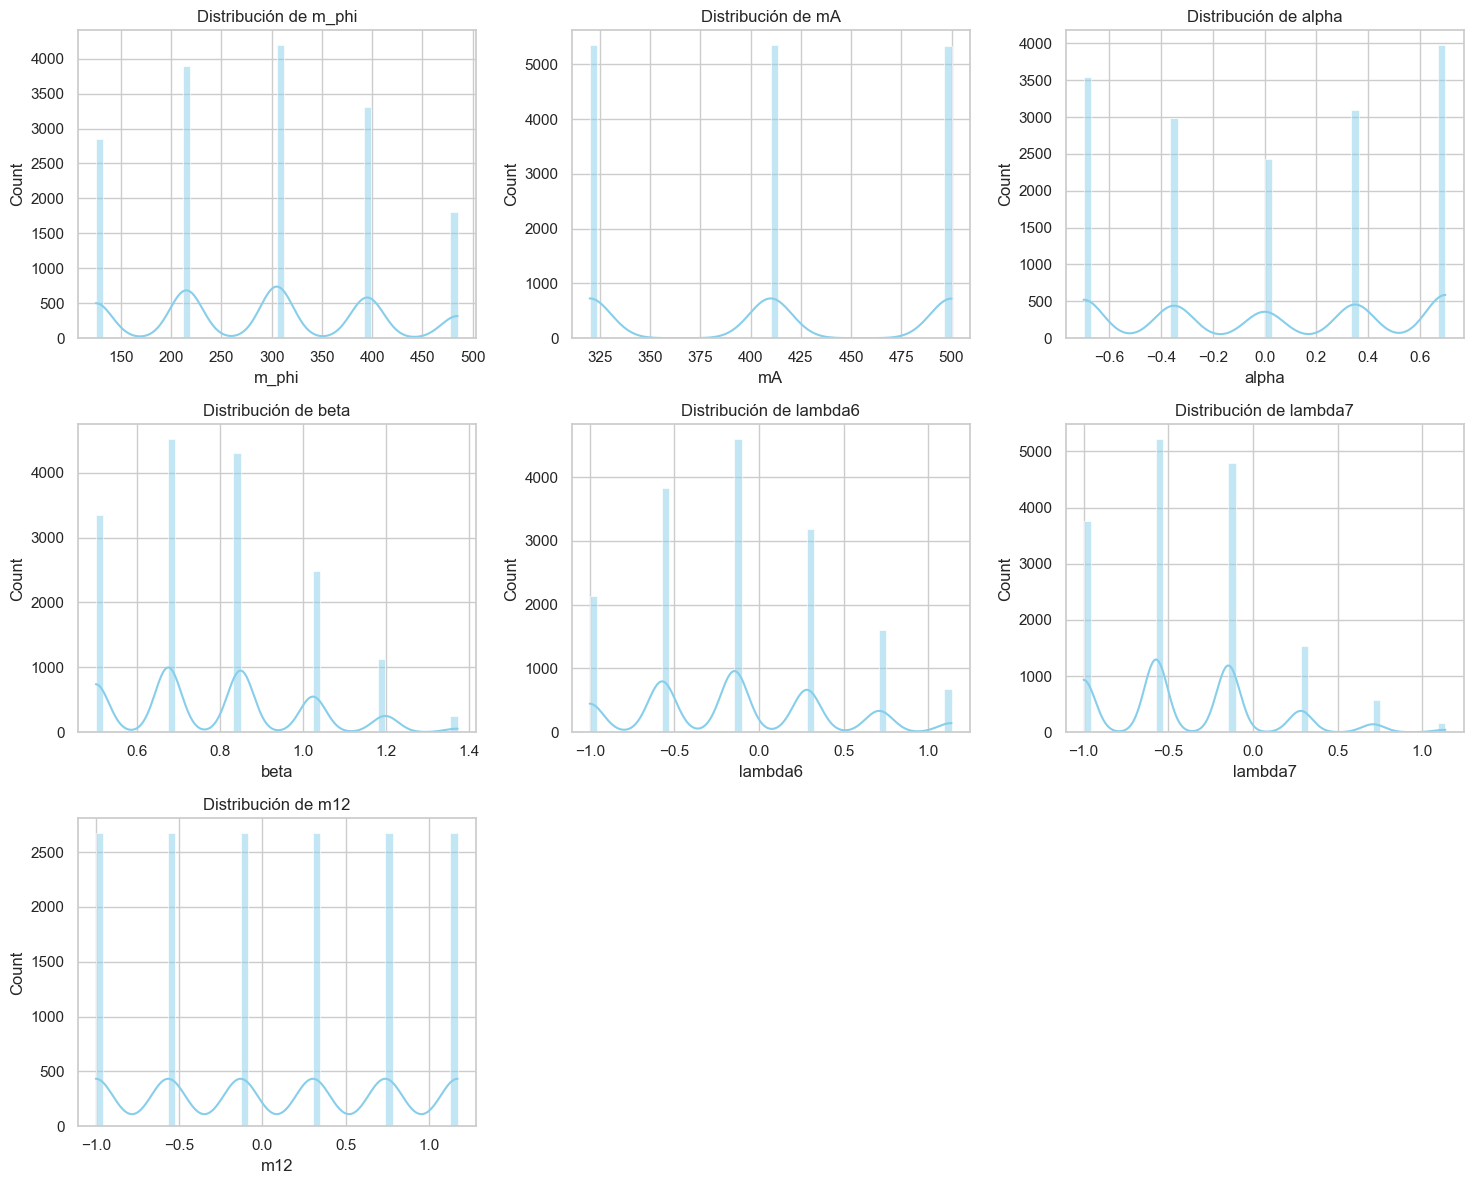

In [6]:
# Graficar histogramas para cada uno de los parámetros (usando sample para acelerar)
sample_df = data_labeled.sample(n=N_samples, random_state=42) if data_labeled.shape[0] > 100000 else data_labeled
print("Distribución de etiquetas:")
print(sample_df['label'].value_counts())


fig, axs = plt.subplots(3, 3, figsize=(15,12))
axs = axs.flatten()
for i, col in enumerate(param_cols):
    sns.histplot(sample_df[col], bins=50, ax=axs[i], kde=True, color="skyblue")
    axs[i].set_title(f"Distribución de {col}")
for j in range(len(param_cols), len(axs)):
    axs[j].axis('off')
plt.tight_layout()
plt.show()


In [8]:
del data_labeled

In [7]:
# Seleccionar features y target
X = sample_df[param_cols].values
y = sample_df['label'].values

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Crear un pipeline: escalado, reducción de dimensionalidad (PCA) y clasificación
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=3)),  # Reducir a 3 componentes para visualización (opcional)
    ('clf', LogisticRegression(random_state=42))
])

pipeline.fit(X_train, y_train)

# Evaluar en conjunto de prueba
y_pred = pipeline.predict(X_test)
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]))


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

# Reducccion Dimensionalidad

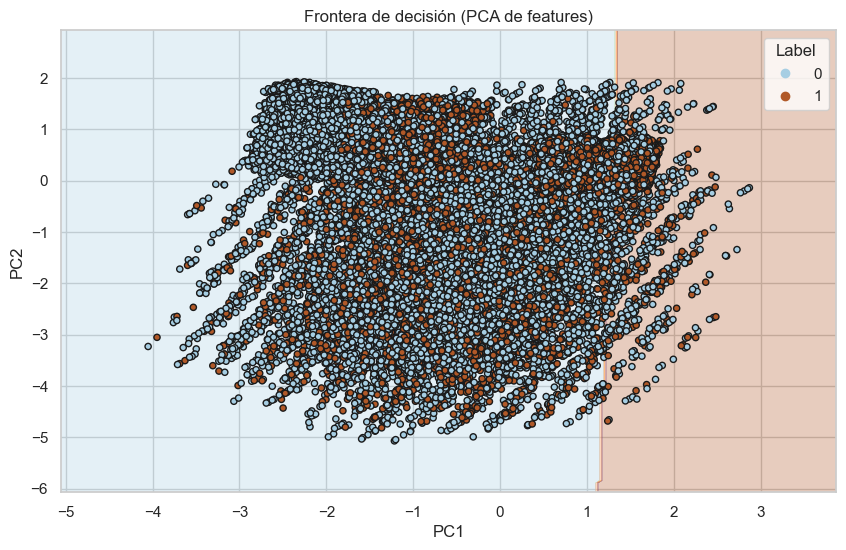

In [10]:
# Reducir el dataset a 2 componentes para visualización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Entrenar un clasificador simple (puede ser el mismo pipeline sin PCA)
clf = LogisticRegression(random_state=42)
clf.fit(X_pca, y)

# Crear malla para graficar la frontera
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.Paired, edgecolor="k", s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Frontera de decisión (PCA de features)")
plt.legend(*scatter.legend_elements(), title="Label")
plt.show()


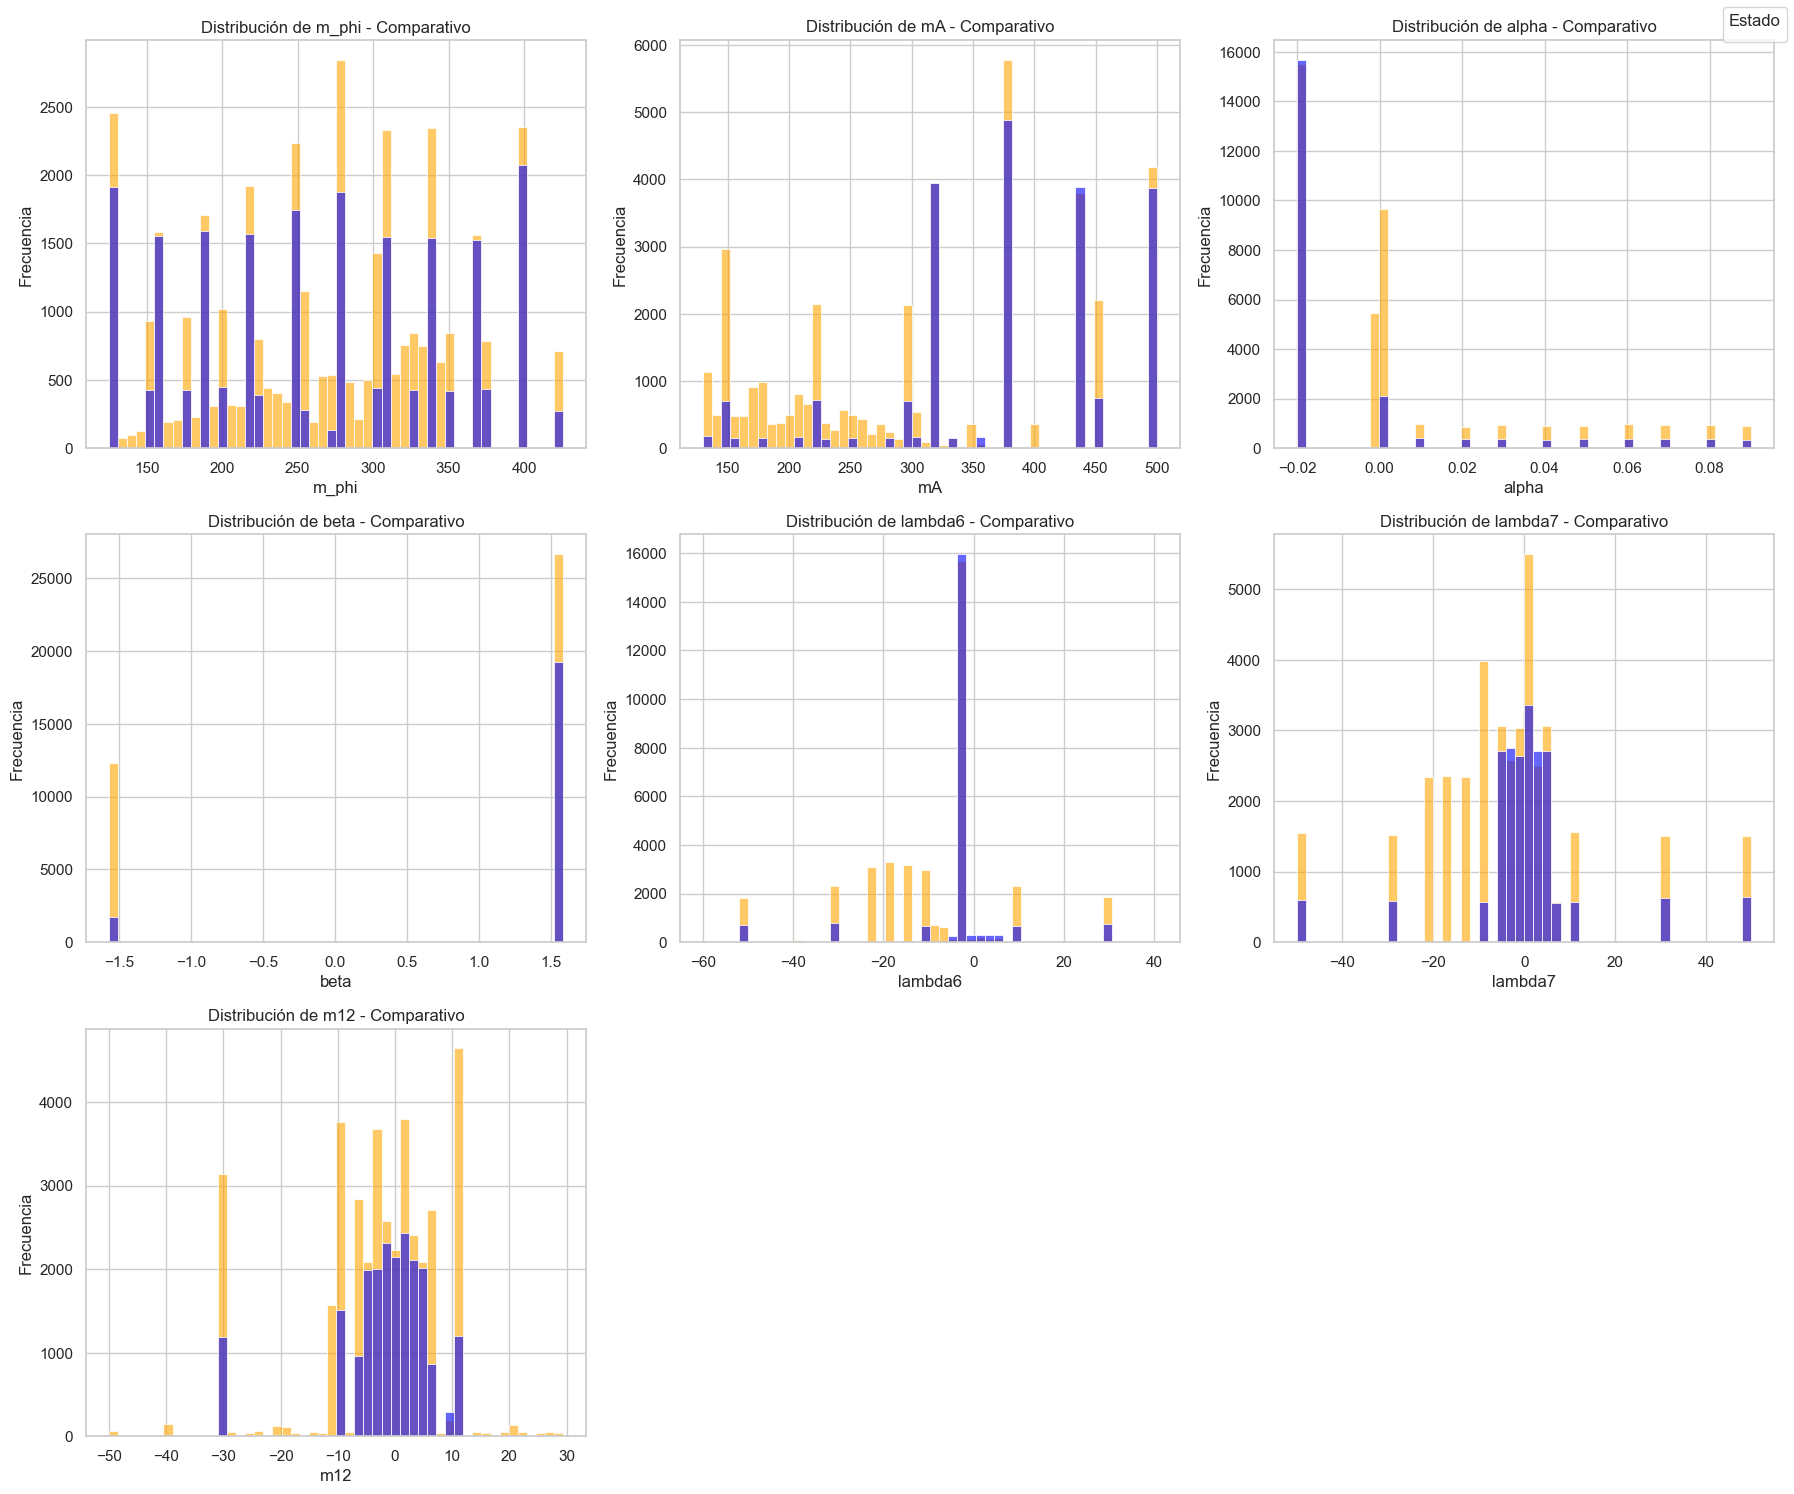

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarnos de que en sample_df tengamos la columna "label" (0 o 1)
# y mapeamos 1 a "Válido" y 0 a "Inválido"
sample_df = sample_df.copy()
sample_df['Condición'] = sample_df['label'].map({1: "Válido", 0: "Inválido"})

# Para asegurar que ambos aparezcan en la leyenda, definimos hue_order:
hue_order = ["Válido", "Inválido"]

fig, axs = plt.subplots(3, 3, figsize=(18, 15))
axs = axs.flatten()

for i, col in enumerate(param_cols):
    ax = axs[i]
    sns.histplot(
        data=sample_df,
        x=col,
        hue="Condición",
        hue_order=hue_order,           # Para forzar el orden de las categorías
        multiple="layer",              # superpone los histogramas
        bins=50,
        alpha=0.6,
        palette={"Válido": "blue", "Inválido": "orange"},
        legend=False,                  # Desactivamos la leyenda en cada subplot
        ax=ax
    )
    ax.set_title(f"Distribución de {col} - Comparativo")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

# Remover ejes sobrantes si param_cols < 9
for j in range(len(param_cols), len(axs)):
    axs[j].axis('off')

# Tomar los handles y labels de uno de los subplots para la leyenda global
handles, labels = axs[0].get_legend_handles_labels()

# Crear la leyenda compartida para toda la figura
fig.legend(handles, labels, title="Estado", loc="upper right")

plt.tight_layout()
plt.show()


In [12]:
# Guardar el pipeline y el dataset preprocesado para su uso futuro en el clúster
with open("model_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)
    
# Guardar el dataset etiquetado (o la muestra) para análisis posterior
sample_df.to_pickle("labeled_sample.pkl")
print("Pipeline y muestra guardados en formato pickle.")


Pipeline y muestra guardados en formato pickle.


## Alternativas a PCA

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP


# Si deseas usar UMAP, descomenta la siguiente línea (y asegúrate de tener 'umap-learn' instalado).
# from umap import UMAP

# ------------------------------------------------
# 1) Definir una función para reducción de dimensión
# ------------------------------------------------
def reduce_dimension(X, method='pca', n_components=2, random_state=42):
    """
    Aplica reducción de dimensionalidad al dataset X.
    - method: 'pca', 'tsne', 'umap'
    - n_components: número de dimensiones deseadas
    - random_state: semilla para reproducibilidad
    """
    if method == 'pca':
        dr = PCA(n_components=n_components, random_state=random_state)
        X_dr = dr.fit_transform(X)
    elif method == 'tsne':
        dr = TSNE(n_components=n_components, random_state=random_state)
        X_dr = dr.fit_transform(X)
    elif method == 'umap':
        # Asegúrate de tener instalada la librería umap-learn
        dr = UMAP(n_components=n_components, random_state=random_state)
        X_dr = dr.fit_transform(X)
    else:
        raise ValueError(f"Método desconocido: {method}")
    return X_dr

# ------------------------------------------------
# 2) Función para graficar frontera de decisión
# ------------------------------------------------
def plot_decision_boundary(X_dr, y, clf, title="Frontera de decisión"):
    """
    Grafica la frontera de decisión para un clasificador 'clf' 
    entrenado en el espacio X_dr (2D). 'y' son las clases (0 o 1).
    """
    # Definir un colormap que asigne color naranja a 0 y azul a 1
    cmap_custom = ListedColormap(["orange", "blue"])
    
    # Crear malla
    x_min, x_max = X_dr[:, 0].min() - 1, X_dr[:, 0].max() + 1
    y_min, y_max = X_dr[:, 1].min() - 1, X_dr[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    # Predecir sobre la malla
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Graficar la frontera de decisión
    plt.figure(figsize=(10,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_custom)
    
    # Graficar puntos
    scatter = plt.scatter(
        X_dr[:, 0], 
        X_dr[:, 1], 
        c=y, 
        cmap=cmap_custom, 
        edgecolor="k", 
        s=20
    )
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.title(title)
    
    # Crear leyenda personalizada
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Inválido (0)',
               markerfacecolor='orange', markeredgecolor='k', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Válido (1)',
               markerfacecolor='blue', markeredgecolor='k', markersize=8)
    ]
    plt.legend(handles=legend_elements, loc="upper right")
    plt.show()




c:\Users\fbien.DESKTOP-6FMEAR7\Desktop\mlclassic_kosmos\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
X_scaled.shape # random sample this for 1e4 points


(60000, 7)

c:\Users\fbien.DESKTOP-6FMEAR7\Desktop\mlclassic_kosmos\env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\fbien.DESKTOP-6FMEAR7\Desktop\mlclassic_kosmos\env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


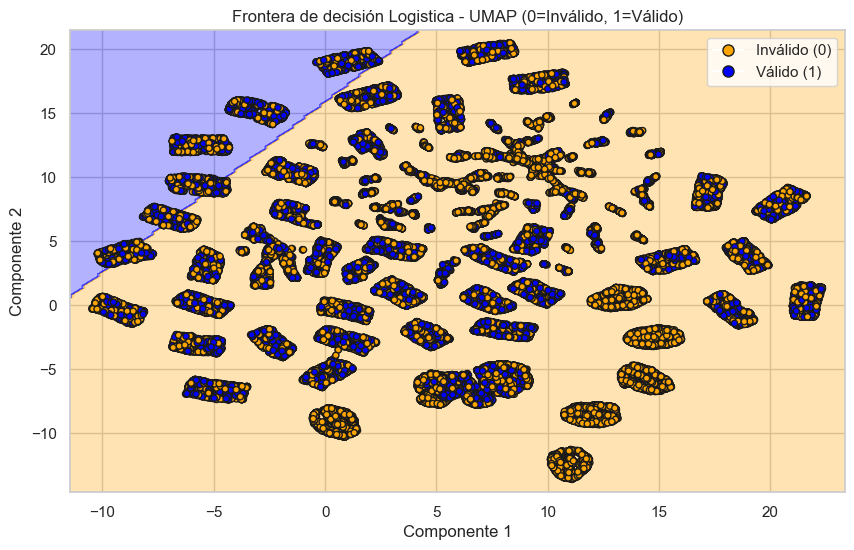

In [15]:
# 3.3 Reducir dimensión con un método (puedes cambiar 'pca' a 'tsne' o 'umap')
method = 'umap'  # 'pca', 'tsne' o 'umap'
X_dr = reduce_dimension(X_scaled, method=method, n_components=2)

# 3.4 Entrenar un clasificador (Logistic Regression)
clf = LogisticRegression(random_state=42)
clf.fit(X_dr, y)

# 3.5 Graficar la frontera de decisión
plot_decision_boundary(X_dr, y, clf,
                    title=f"Frontera de decisión Logistica - {method.upper()} (0=Inválido, 1=Válido)")

Silhouette Score (GMM): 0.3031921901783068
Adjusted Rand Index comparando clusters con etiquetas originales: 0.09257661493180618


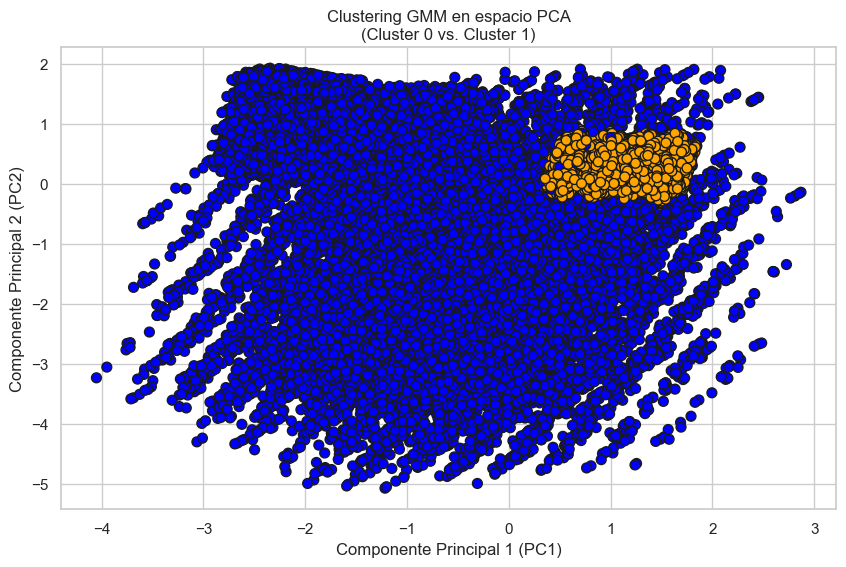

In [16]:
# -----------------------
# Parte 10: Clustering con GMM para separar en 2 clusters y analizar el espacio paramétrico
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap


X_scaled = X_scaled
sample_df = sample_df

# Entrenar un modelo GMM con 2 componentes (clusters)
gmm = GaussianMixture(n_components=2, random_state=42)
cluster_labels = gmm.fit_predict(X_scaled)

# Calcular el silhouette score para evaluar la calidad del clustering
sil_score = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score (GMM):", sil_score)

# Si contamos con las etiquetas originales ('label'), se puede evaluar la concordancia con el clustering
if "label" in sample_df.columns:
    # Usamos Adjusted Rand Index (ARI), que es invariante al intercambio de etiquetas
    ari = adjusted_rand_score(sample_df["label"], cluster_labels)
    print("Adjusted Rand Index comparando clusters con etiquetas originales:", ari)

# Visualización: Reducir la dimensionalidad a 2 componentes usando PCA para graficar
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_scaled)

# Definir un colormap personalizado: asignar naranja a un cluster y azul al otro
cmap_custom = ListedColormap(["orange", "blue"])

plt.figure(figsize=(10,6))
plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=cluster_labels, cmap=cmap_custom,
            edgecolor="k", s=50)
plt.xlabel("Componente Principal 1 (PC1)")
plt.ylabel("Componente Principal 2 (PC2)")
plt.title("Clustering GMM en espacio PCA\n(Cluster 0 vs. Cluster 1)")
plt.show()


# Autoencoder


In [17]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score, adjusted_rand_score
# from sklearn.decomposition import PCA
# from matplotlib.colors import ListedColormap

# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# # ---------------------
# # Entrenamiento de Autoencoder para reducción no lineal
# input_dim = X_scaled.shape[1]
# encoding_dim = 3  # Puedes ajustar esto

# input_layer = Input(shape=(input_dim,))
# encoded = Dense(16, activation='relu')(input_layer)
# encoded = Dense(8, activation='relu')(encoded)
# latent = Dense(encoding_dim, activation='linear', name='latent_space')(encoded)
# decoded = Dense(8, activation='relu')(latent)
# decoded = Dense(16, activation='relu')(decoded)
# output_layer = Dense(input_dim, activation='linear')(decoded)

# autoencoder = Model(input_layer, output_layer)
# encoder = Model(input_layer, latent)

# autoencoder.compile(optimizer=Adam(1e-3), loss='mse')
# autoencoder.fit(X_scaled, X_scaled,
#                 epochs=100,
#                 batch_size=64,
#                 validation_split=0.1,
#                 verbose=0,
#                 callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])

# # ---------------------
# # Codificar al espacio latente
# X_latent = encoder.predict(X_scaled)

# # ---------------------
# # Clustering GMM en espacio latente
# gmm = GaussianMixture(n_components=2, random_state=42)
# cluster_labels = gmm.fit_predict(X_latent)

# sil_score = silhouette_score(X_latent, cluster_labels)
# print("Silhouette Score (GMM en espacio latente):", sil_score)

# if "label" in sample_df.columns:
#     ari = adjusted_rand_score(sample_df["label"], cluster_labels)
#     print("Adjusted Rand Index comparando clusters con etiquetas originales:", ari)

# # ---------------------
# # Visualización en 2D usando PCA para graficar
# pca_vis = PCA(n_components=2, random_state=42)
# X_vis = pca_vis.fit_transform(X_latent)

# cmap_custom = ListedColormap(["orange", "blue"])
# plt.figure(figsize=(10,6))
# plt.scatter(X_vis[:, 0], X_vis[:, 1], c=cluster_labels, cmap=cmap_custom,
#             edgecolor="k", s=50)
# plt.xlabel("PC1 (espacio latente)")
# plt.ylabel("PC2 (espacio latente)")
# plt.title("Clustering GMM tras Autoencoder\n(Cluster 0 vs. Cluster 1)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


## Conclusiones y Próximos Pasos

En este notebook se ha creado un pipeline que:
- Carga y explora el dataset obtenido del escaneo de parámetros.
- Permite definir una condición física (por ejemplo, que los tres flags sean 1 o combinaciones específicas) y genera una etiqueta binaria.
- Separa el dataset en training y test para entrenar un clasificador (en este ejemplo, regresión logística) que predice si un punto cumple la condición.
- Visualiza las fronteras de decisión en un espacio de dos dimensiones (usando PCA).
- Guarda el modelo entrenado y la muestra etiquetada para uso futuro en el clúster.

Como próximos pasos, se puede experimentar con modelos bayesianos (por ejemplo, utilizando GaussianProcessClassifier o modelos en PyMC3) para capturar la incertidumbre en la predicción y guiar la exploración del espacio paramétrico. Además, se pueden aplicar técnicas de reducción de dimensionalidad (t-SNE, UMAP) para visualizar en detalle las regiones de interés.

¡Este notebook deja una base funcional para luego escalar el análisis y ejecutar en el clúster!
